# HESS I

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from iactrace import MCIntegrator, Telescope, hexshow, show_telescope, squareshow

## Import HESS I telescope configuration:

In [2]:
telescope = Telescope.from_yaml('../../configs/HESS/CT3.yaml', MCIntegrator(256), key = jax.random.key(42))

Apply mirror roughness (in arcseconds) due to imperfect surface:

In [3]:
telescope = telescope.apply_roughness(24)

## Visualizing telescope:

In [4]:
scene = show_telescope(telescope)
scene.show(viewer='jupyter')

## Simulating a star field:

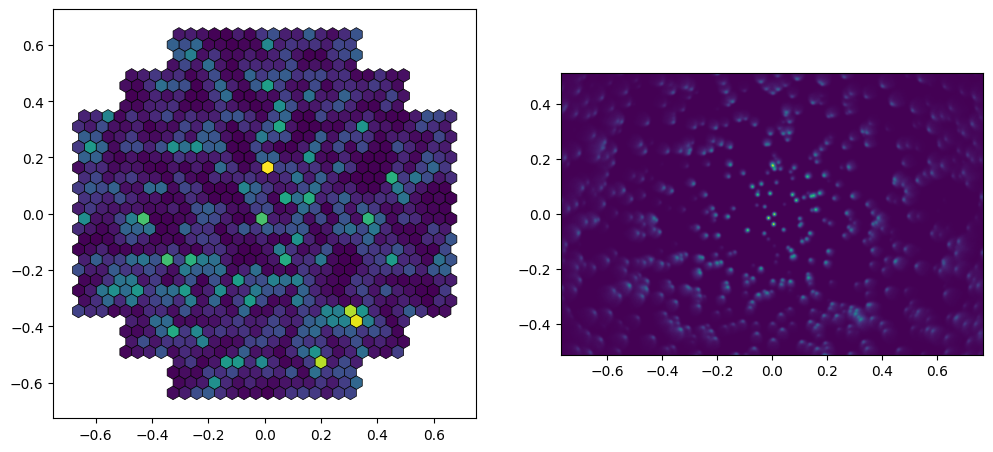

In [5]:
# Generate star field
n_stars = 1000
key = jax.random.key(42)
key1, key2 = jax.random.split(key)

# Small angular region (6 degrees field of view)
fov_deg = 6
fov_rad = fov_deg * jnp.pi / 180

x = jax.random.uniform(key1, (n_stars,), minval=-fov_rad/2, maxval=fov_rad/2)
y = jax.random.uniform(key2, (n_stars,), minval=-fov_rad/2, maxval=fov_rad/2)
z = -jnp.ones(n_stars)

stars = jnp.stack([x, y, z], axis=1)
stars = stars / jnp.linalg.norm(stars, axis=1, keepdims=True)

# Set random flux values for stars:
key = jax.random.key(4242)
f_stars = jax.random.uniform(key, shape=(len(stars),))

# Render images
image_science = telescope.render(stars, f_stars, source_type='parallel', sensor_idx=0)
image_lid = telescope.render(stars, f_stars, source_type='parallel', sensor_idx=1)

# Visualize
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
ax_hex = hexshow(image_science, telescope.sensors[0], ax=ax[0])
ax_lid = squareshow(image_lid, telescope.sensors[1], ax=ax[1])

## Simulating a point source at finite distance:

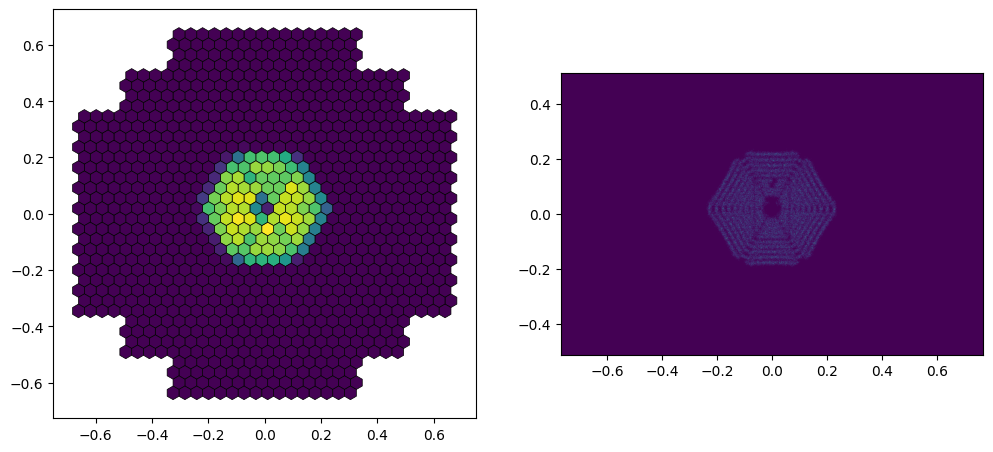

In [6]:
# Creating a random point at 500m distance to create Bokeh effect:
N_points = 1

key = jax.random.key(45)
key1, key2 = jax.random.split(key)

x = jax.random.uniform(key1, N_points, minval=-1, maxval=1)
y = jax.random.uniform(key2, N_points, minval=-1, maxval=1)
z = jnp.ones(N_points) * 500

points = jnp.array([x,y,z]).T
f_points = jnp.ones(len(points))

# Render point source images
image_science = telescope.render(points, f_points, source_type='point', sensor_idx=0)
image_lid = telescope.render(points, f_points, source_type='point', sensor_idx=1)

# Visualize
fig, ax = plt.subplots(ncols=2, figsize=(12,6))
ax_hex = hexshow(image_science, telescope.sensors[0], ax=ax[0])
ax_lid = squareshow(image_lid, telescope.sensors[1], ax=ax[1])

## Tracing actual rays:
Sometimes you just need to trace actual rays...

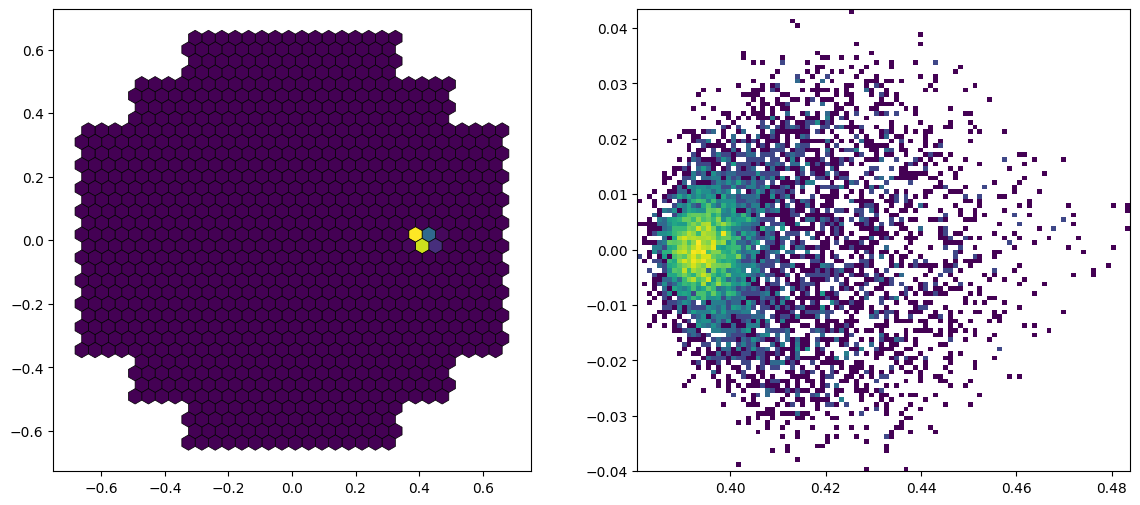

In [15]:
# We create a disk of 6m radius of 10000 rays:
n_rays = 10000
key = jax.random.key(123)
key1, key2 = jax.random.split(key)

r = 6.0 * jnp.sqrt(jax.random.uniform(key1, (n_rays,)))
theta = jax.random.uniform(key2, (n_rays,)) * 2 * jnp.pi
ray_origins = jnp.stack([
    r * jnp.cos(theta),
    r * jnp.sin(theta),
    jnp.ones(n_rays) * 100.0
], axis=1)

# Tilt rays by 1.5 degrees
tilt_angle = 1.5 * jnp.pi / 180
ray_directions = jnp.broadcast_to(
    jnp.array([jnp.sin(tilt_angle), 0.0, -jnp.cos(tilt_angle)]),
    (n_rays, 3)
)
ray_values = jnp.ones(n_rays)

# Trace through telescope and assign to sensor + debug mode for spot diagram:
image_rays = telescope.trace(ray_origins, ray_directions, ray_values, sensor_idx=0)
ray_debug = telescope.trace(ray_origins, ray_directions, ray_values, sensor_idx=0, debug=True)

# Visualize
fig, ax = plt.subplots(ncols=2, figsize=(14, 6))
ax_hex = hexshow(image_rays, telescope.sensors[0], ax=ax[0])
ax_scatter = ax[1].hist2d(ray_debug[0][ray_debug[2] > 0, 0], ray_debug[0][ray_debug[2] > 0, 1], bins=100, norm='log')